In [2]:
!pip install xgboost
!pip install shap


  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ------------------------------------- -- 524.3/555.9 kB 2.9 MB/s eta 0:00:01
   ---------------------------------------- 555.9/555.9 kB 2.6 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [3]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, recall_score, precision_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, precision_recall_curve, roc_curve
)
from sklearn.preprocessing import LabelEncoder
import shap

In [14]:
# 2. Data Loading & Initial Cleaning
df = pd.read_csv('D:\\DS-Proj-git\\ds-mini-project\\data\\ml_data\\Feature_Engineered.csv', low_memory=False)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Remove anomalous data points (e.g., 2023 having only 7 rows)
df = df[df['renewal_year'] != 2023]
df = df.drop(columns=['renewal_year'], errors='ignore')


In [18]:
# 3. Feature Encoding
cat_cols = [
    'proforma_account_stage', 'proforma_audit_status', 'current_world_pay_token',
    'proforma_membership_status', 'band', 'connection_group', 'tenure_group',
    'last_band', 'sentiment_category','cc_worst_sentiment','desire_to_cancel_agg','flag_risk_level','tenure_bucket'
]
cat_cols = [c for c in cat_cols if c in df.columns]

encoders = {}
for col in cat_cols:
    df[col] = df[col].astype(str).fillna('missing')
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le


In [19]:
# 4. Train-Test Split & Class Weights

# Separate target and features
X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Calculate weight for imbalanced classes
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()


In [27]:
#null check
for col in df.columns:
    null_count = df[col].isnull().sum()
    print(f"{col}: {null_count} null values")

proforma_account_stage: 0 null values
proforma_audit_status: 0 null values
current_world_pay_token: 0 null values
proforma_membership_status: 0 null values
tenure_years: 0 null values
band: 0 null values
amount: 0 null values
connection_group: 0 null values
tenure_group: 0 null values
#_of_connection: 0 null values
last_band: 0 null values
last_connections: 0 null values
price_change: 0 null values
churn: 0 null values
crm_contractor_sentiment_score_num: 13725 null values
sentiment_category: 0 null values
total_calls: 0 null values
outbound_calls: 0 null values
inbound_calls: 0 null values
max_call_number: 0 null values
num_analysed_calls: 0 null values
serious_complaint_flag: 0 null values
other_complaint_flag: 0 null values
price_discussed_flag: 0 null values
discount_requested_flag: 0 null values
call_reschedule_flag: 0 null values
membership_alert_flag: 0 null values
competitor_mentioned_flag: 0 null values
switching_intent_flag: 0 null values
price_switching_flag: 0 null values
pc

In [20]:
# 5. Model Training
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

model.fit(X_train, y_train)

# Generate predictions and probabilities
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

In [21]:
# 6. Evaluation Metrics
print('--- Baseline Evaluation ---')
print(f"Accuracy:          {accuracy_score(y_test, pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, pred):.3f}")
print(f"ROC-AUC:           {roc_auc_score(y_test, proba):.3f}")
print(f"PR-AUC:            {average_precision_score(y_test, proba):.3f}")
print("\nClassification Report:\n", classification_report(y_test, pred))

--- Baseline Evaluation ---
Accuracy:          0.850
Balanced Accuracy: 0.823
ROC-AUC:           0.902
PR-AUC:            0.637

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.86      0.91      5137
           1       0.42      0.79      0.55       673

    accuracy                           0.85      5810
   macro avg       0.70      0.82      0.73      5810
weighted avg       0.91      0.85      0.87      5810



In [22]:
# 7. Threshold Tuning
thresholds = np.arange(0.1, 0.8, 0.02)
results = []

for t in thresholds:
    pred_t = (proba >= t).astype(int)
    results.append({
        'threshold': t,
        'balanced_acc': balanced_accuracy_score(y_test, pred_t),
        'recall': recall_score(y_test, pred_t),
        'precision': precision_score(y_test, pred_t, zero_division=0)
    })

results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['balanced_acc'].idxmax()]
best_threshold = best_row['threshold']

print('--- Optimized Evaluation ---')
print(f"Best Threshold (by Balanced Acc): {best_threshold:.2f}")

pred_final = (proba >= best_threshold).astype(int)
print(classification_report(y_test, pred_final))


--- Optimized Evaluation ---
Best Threshold (by Balanced Acc): 0.44
              precision    recall  f1-score   support

           0       0.97      0.83      0.90      5137
           1       0.39      0.82      0.53       673

    accuracy                           0.83      5810
   macro avg       0.68      0.83      0.71      5810
weighted avg       0.90      0.83      0.85      5810



CV Balanced Accuracy: 0.825 (std: 0.009)


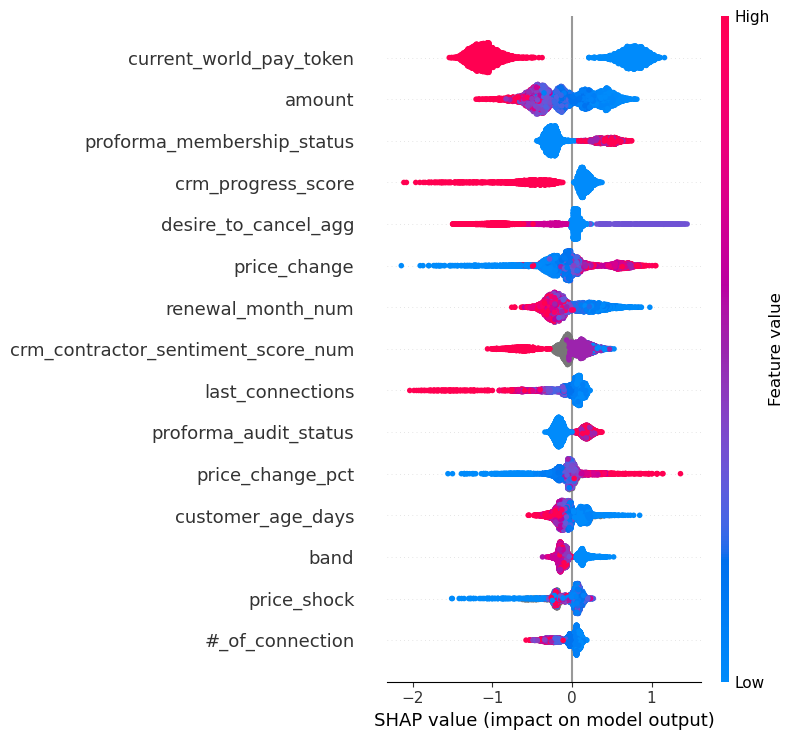

In [23]:
# 8. Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
print(f"CV Balanced Accuracy: {cv_scores.mean():.3f} (std: {cv_scores.std():.3f})")

# 9. Feature Importance (SHAP)
explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_test, max_display=15)